In [11]:
#!pip install -q kagglehub

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import cohen_kappa_score


In [12]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define Paths
BASE_DIR = kagglehub.dataset_download("mariaherrerot/aptos2019")
TRAIN_CSV_PATH = os.path.join(BASE_DIR, 'train_1.csv')
VALID_CSV_PATH = os.path.join(BASE_DIR, 'valid.csv')

# Inspect CSVs
train_df = pd.read_csv(TRAIN_CSV_PATH)
valid_df = pd.read_csv(VALID_CSV_PATH)

print(f"Train set size: {len(train_df)}")
print(f"Valid set size: {len(valid_df)}")
print("\nTrain DataFrame Head:")
print(train_df.head())

# Check for Class Imbalance
print("\nClass Counts in Training Set:")
print(train_df['diagnosis'].value_counts().sort_index())

# Verify Image Paths
#
train_dir_check = os.path.join(BASE_DIR, 'train_images', 'train_images')
if os.path.exists(train_dir_check):
    print(f"\nConfirmed Train Image Directory: {train_dir_check}")
else:
    print(f"\nWARNING: Could not find {train_dir_check}. Checking parent folder...")
    print(os.listdir(os.path.join(BASE_DIR, 'train_images')))

Using device: cpu
Using Colab cache for faster access to the 'aptos2019' dataset.
Train set size: 2930
Valid set size: 366

Train DataFrame Head:
        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0

Class Counts in Training Set:
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64

Confirmed Train Image Directory: /kaggle/input/aptos2019/train_images/train_images


In [ ]:
from PIL import Image
from torchvision import transforms

# Ben Graham's Preprocessing Method
def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1),mask.any(0))]
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        check_shape = img[:,:,0][np.ix_(mask.any(1),mask.any(0))].shape[0]
        if (check_shape == 0):
            return img
        else:
            img1=img[:,:,0][np.ix_(mask.any(1),mask.any(0))]
            img2=img[:,:,1][np.ix_(mask.any(1),mask.any(0))]
            img3=img[:,:,2][np.ix_(mask.any(1),mask.any(0))]
            img = np.stack([img1,img2,img3],axis=-1)
        return img

def preprocess_image(image_path, sigmaX=10):
    image = cv2.imread(image_path)
    if image is None:
        # Error handling if image is not found
        print(f"ERROR: Could not read {image_path}")
        # Return a blank black image to prevent crash
        return Image.fromarray(np.zeros((256, 256, 3), dtype=np.uint8))

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = crop_image_from_gray(image)
    image = cv2.resize(image, (224, 224)) # Changed to 224x224
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigmaX), -4, 128)
    return Image.fromarray(image)

# Custom Dataset Class
class RetinopathyDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir # Now we pass the specific folder path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['id_code'] + '.png'
        # Construct path using the specific directory passed in __init__
        img_path = os.path.join(self.image_dir, img_name)

        image = preprocess_image(img_path)
        label = torch.tensor(int(row['diagnosis']), dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

# Data Transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)), # Changed to 224x224
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Weighted Sample
class_counts = train_df['diagnosis'].value_counts().sort_index().values
class_weights = 1. / class_counts
sample_weights = [class_weights[label] for label in train_df['diagnosis']]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Create Loaders
# Note: Based on your screenshot, 'val_images' folder exists
TRAIN_IMG_PATH = os.path.join(BASE_DIR, 'train_images', 'train_images')
VALID_IMG_PATH = os.path.join(BASE_DIR, 'val_images', 'val_images')

print(f"Train Images Path: {TRAIN_IMG_PATH}")
print(f"Valid Images Path: {VALID_IMG_PATH}")

train_dataset = RetinopathyDataset(train_df, TRAIN_IMG_PATH, transform=data_transforms['train'])
valid_dataset = RetinopathyDataset(valid_df, VALID_IMG_PATH, transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2)
val_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False, num_workers=2)

print("Data Loaders Ready (Paths Corrected).")

Train Images Path: /kaggle/input/aptos2019/train_images/train_images
Valid Images Path: /kaggle/input/aptos2019/val_images/val_images
Data Loaders Ready (Paths Corrected).


In [4]:
# #  Define the Model
# # Load pretrained ResNet50
# model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# # Freeze the early layers?
# # For highest accuracy, we usually DON'T freeze everything,
# # but we stick to a low learning rate to fine-tune the whole network.

# # Replace the final fully connected layer
# # ResNet50's last layer is called 'fc' and has 2048 input features.
# num_ftrs = model.fc.in_features
# model.fc = nn.Linear(num_ftrs, 5) # 5 output classes (0-4)

# # Move to GPU
# model = model.to(device)

# # Loss and Optimizer
# criterion = nn.CrossEntropyLoss()

# # Adam
# # 1e-4 is a safe learning rate for fine-tuning.
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# print("Model loaded: ResNet50")
# print("Final layer modified for 5 classes.")
# print(f"Model moved to: {device}")

In [14]:
import os
from google.colab import userdata

try:
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
    print('HF_TOKEN successfully set from secrets.')
except Exception as e:
    print(f'Erro ao carregar HF_TOKEN: {e}')
    print('Note: HF_TOKEN not set, but public models should still download. Please ensure the secret is named HF_TOKEN in Colab.')

HF_TOKEN successfully set from secrets.


In [16]:
# CoAtNet-0 via timm

# !pip install -q timm

import timm
import torch
import torch.nn as nn

# List available CoAtNet models
print("Available CoAtNet models in timm:")
for model_name in timm.list_models('*coatnet*'):
    print(model_name)

model = timm.create_model(
    'coatnet_0_rw_224',
    pretrained=True,
    num_classes=5
)

# Move to device
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Model loaded: coatnet_0_rw_224 (timm, pretrained)")
print("Output classes: 5 (Diabetic Retinopathy levels)")
print(f"Running on device: {device}")

Available CoAtNet models in timm:
coatnet_0_224
coatnet_0_rw_224
coatnet_1_224
coatnet_1_rw_224
coatnet_2_224
coatnet_2_rw_224
coatnet_3_224
coatnet_3_rw_224
coatnet_4_224
coatnet_5_224
coatnet_bn_0_rw_224
coatnet_nano_cc_224
coatnet_nano_rw_224
coatnet_pico_rw_224
coatnet_rmlp_0_rw_224
coatnet_rmlp_1_rw2_224
coatnet_rmlp_1_rw_224
coatnet_rmlp_2_rw_224
coatnet_rmlp_2_rw_384
coatnet_rmlp_3_rw_224
coatnet_rmlp_nano_rw_224
Model loaded: coatnet_0_rw_224 (timm, pretrained)
Output classes: 5 (Diabetic Retinopathy levels)
Running on device: cpu


In [17]:
# TRAINING FUNCTIon
import time
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_kappa = 0.0

    print("Starting training function...")

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # --- TRAIN PHASE ---
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # --- VALIDATION PHASE ---
        model.eval()
        val_running_corrects = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

                val_running_corrects += torch.sum(preds == labels.data)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_acc = val_running_corrects.double() / len(val_loader.dataset)
        kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

        print(f'Valid Acc:  {val_acc:.4f}')
        print(f'Valid Kappa: {kappa:.4f}')

        if val_acc > best_acc:
            best_acc = val_acc
            best_kappa = kappa
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_model.pth')
            print("-> Best model saved!")

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:.4f}')
    print(f'Best Val Kappa: {best_kappa:.4f}')

    model.load_state_dict(best_model_wts)
    return model

In [18]:
print("Starting Full Training on the complete dataset...")

model = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Starting Full Training on the complete dataset...
Starting training function...

Epoch 1/5
----------
Train Loss: 1.0271 Acc: 0.5502
Valid Acc:  0.7842
Valid Kappa: 0.8798
-> Best model saved!

Epoch 2/5
----------
Train Loss: 0.8170 Acc: 0.6618
Valid Acc:  0.7842
Valid Kappa: 0.8715

Epoch 3/5
----------
Train Loss: 0.6802 Acc: 0.7304
Valid Acc:  0.6940
Valid Kappa: 0.8226

Epoch 4/5
----------
Train Loss: 0.6170 Acc: 0.7573
Valid Acc:  0.7077
Valid Kappa: 0.8428

Epoch 5/5
----------
Train Loss: 0.5653 Acc: 0.7754
Valid Acc:  0.6557
Valid Kappa: 0.8337

Training complete in 178m 21s
Best Val Acc: 0.7842
Best Val Kappa: 0.8798


Generating Confusion Matrix...


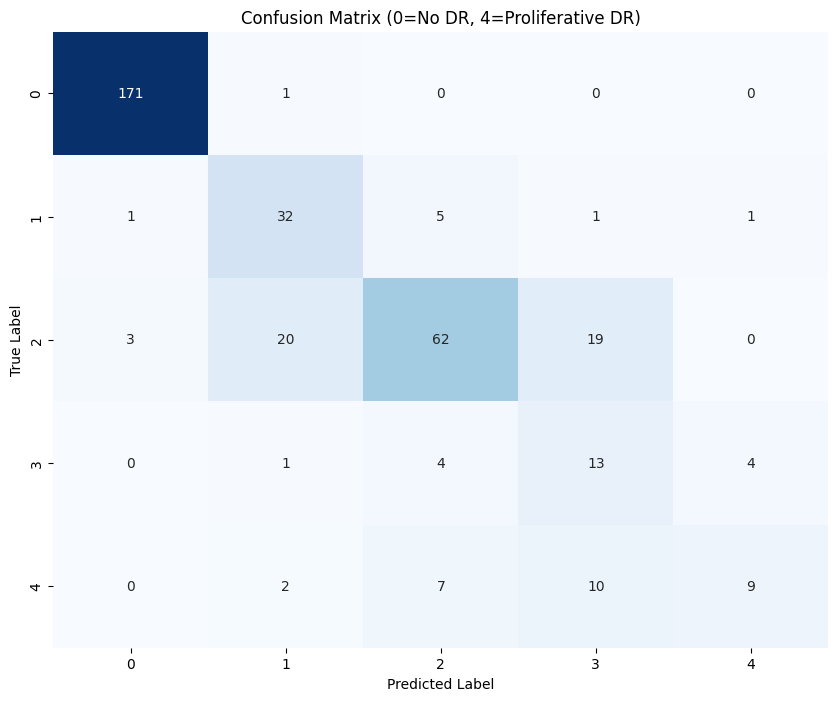


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       172
           1       0.57      0.80      0.67        40
           2       0.79      0.60      0.68       104
           3       0.30      0.59      0.40        22
           4       0.64      0.32      0.43        28

    accuracy                           0.78       366
   macro avg       0.66      0.66      0.63       366
weighted avg       0.81      0.78      0.79       366



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    print("Generating Confusion Matrix...")
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    cm = confusion_matrix(all_labels, all_preds)

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (0=No DR, 4=Proliferative DR)')
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

# Run visualization on the validation set
plot_confusion_matrix(model, val_loader, device)

In [20]:
# SETUP TEST DATA (Required for Dashboard)
import os
import pandas as pd
from torch.utils.data import Dataset

# Define Paths
TEST_CSV_PATH = os.path.join(BASE_DIR, 'test.csv')
TEST_IMG_PATH = os.path.join(BASE_DIR, 'test_images', 'test_images')

#Load the CSV
test_df = pd.read_csv(TEST_CSV_PATH)
print(f"Found {len(test_df)} test images.")

#Define the Test Dataset Class
class RetinopathyTestDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['id_code'] + '.png'
        img_path = os.path.join(self.image_dir, img_name)

        # Use the existing preprocessing we done before
        image = preprocess_image(img_path)

        if self.transform:
            image = self.transform(image)

        # Return image and ID (instead of label)
        return image, row['id_code']

#Create the Dataset Object
test_dataset = RetinopathyTestDataset(test_df, TEST_IMG_PATH, transform=data_transforms['val'])

print("Test Dataset loaded! You can now run the dashboard cell.")

Found 366 test images.
Test Dataset loaded! You can now run the dashboard cell.


Visualizing a random patient from Test Set...


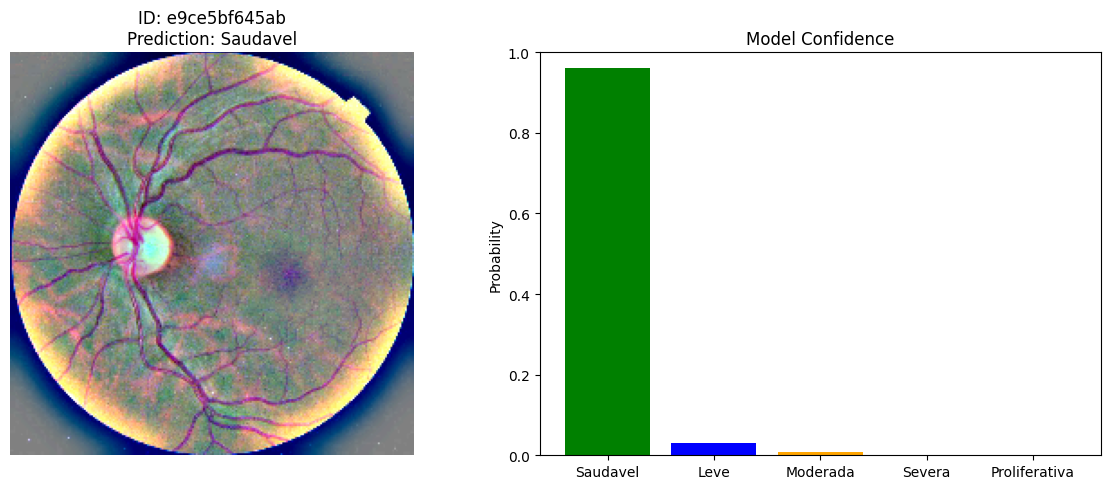

In [27]:
import torch.nn.functional as F

def visualize_prediction(model, dataset, index=None):
    model.eval()

    # Pick random image
    if index is None:
        index = np.random.randint(0, len(dataset))

    image, img_id = dataset[index]

    #Prepare batch of 1
    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        # Convert raw output to percentages (probabilities)
        probs = F.softmax(output, dim=1)[0].cpu().numpy()
        pred_label = np.argmax(probs)

    # Mapping labels to names
    class_names = {
        0: "Saudavel",
        1: "Leve",
        2: "Moderada",
        3: "Severa",
        4: "Proliferativa"
    }

    # plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Show Image (Un-normalize for display)
    img_display = image.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    ax1.imshow(img_display)
    ax1.set_title(f"ID: {img_id}\nPrediction: {class_names[pred_label]}")
    ax1.axis('off')

    # Show Probabilities Bar Chart
    colors = ['green', 'blue', 'orange', 'red', 'darkred']
    ax2.bar(class_names.values(), probs, color=colors)
    ax2.set_title("Model Confidence")
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Probability")

    plt.tight_layout()
    plt.show()


print("Visualizing a random patient from Test Set...")
visualize_prediction(model, test_dataset)

Generating Saliency Map (Explainability)...


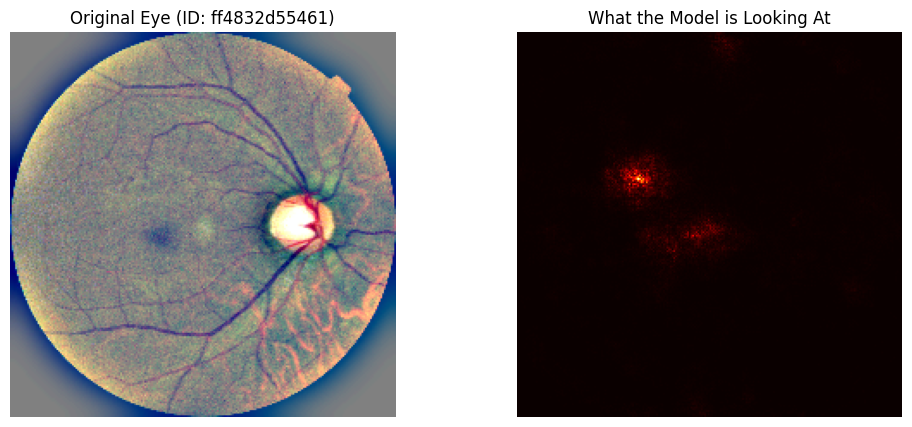

In [25]:
def show_saliency_map(model, dataset, index=None):
    model.eval()
    if index is None:
        index = np.random.randint(0, len(dataset))

    image, img_id = dataset[index]
    input_tensor = image.unsqueeze(0).to(device)

    # We need gradients for this
    input_tensor.requires_grad_()

    output = model(input_tensor)
    score, pred_class_idx = torch.max(output, 1)

    # Backpropagate to get the gradient of the prediction with respect to the input image
    score.backward()

    # Get the gradients (The "importance" of each pixel)
    saliency, _ = torch.max(input_tensor.grad.data.abs(), dim=1)
    saliency = saliency.reshape(224, 224)

    # plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Original
    img_display = image.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    ax1.imshow(img_display)
    ax1.set_title(f"Original Eye (ID: {img_id})")
    ax1.axis('off')

    # Saliency (Heatmap)
    ax2.imshow(saliency.cpu(), cmap='hot')
    ax2.set_title("What the Model is Looking At")
    ax2.axis('off')

    plt.show()

print("Generating Saliency Map (Explainability)...")
show_saliency_map(model, test_dataset)